In [1]:
import sqlite3
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np
from math import log2

DB = '../data/humans_clean.sqlite3'
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

modern = [
    ('USSR',            'Union of Soviet Socialist Republics', 1922, 1991),
    ('East Germany',    'German Democratic Republic',          1949, 1990),
    ('Austria-Hungary', 'Austria-Hungary',                     1868, 1918),
    ('German Empire',   'German Empire',                       1871, 1919),
    ('Nazi Germany',    'Nazi Germany',                        1936, 1944),
    ('Yugoslavia',      'Socialist Federal Republic of Yugoslavia', 1946, 1991),
    ('Weimar Republic', 'Weimar Republic',                     1920, 1935),
    ('Francoist Spain', 'Francoist Spain',                     1939, 1975),
]

ancient = [
    ('Ming Dynasty',    'Ming Dynasty',                        1375, 1644),
    ('Southern Song',   'Southern Song',                       1028, 1278),
    ('Byzantine Empire','Byzantine Empire',                    633,  1474),
    ('Rep. of Venice',  'Republic of Venice',                  735,  1796),
    ('Polish-Lithuanian','Polish-Lithuanian Commonwealth',     1572, 1793),
    ('Swedish Empire',  'Swedish Empire',                      1612, 1814),
    ('Rep. of Florence','Republic of Florence',                1459, 1737),
    ('Mongol Empire',   'Mongol Empire',                       1210, 1293),
]

bin_modern = 10
bin_ancient = 25

mil_kw = ['military', 'soldier', 'officer', 'commander', 'general', 'admiral',
          'colonel', 'army', 'warrior', 'naval officer']
mil_cond = ' OR '.join(f"i.occupations_en LIKE '%{k}%'" for k in mil_kw)

sch_kw = ['researcher', 'scientist', 'professor', 'philosopher', 'mathematician',
          'physicist', 'academic', 'scholar', 'chemist', 'biologist']
sch_cond = ' OR '.join(f"i.occupations_en LIKE '%{k}%'" for k in sch_kw)

cmap = plt.cm.tab10

def shannon_entropy(counter):
    total = sum(counter.values())
    if total == 0:
        return 0
    return -sum((c/total) * log2(c/total) for c in counter.values() if c > 0)

def normalize(curve):
    """Normalize a curve so that the first point = 100 (index)."""
    if not curve:
        return curve
    ts, vs = zip(*curve)
    base = vs[0] if vs[0] != 0 else 1
    return list(zip(ts, [v / base * 100 for v in vs]))

print(f'Modern: {len(modern)}, Ancient: {len(ancient)}')

Modern: 8, Ancient: 8


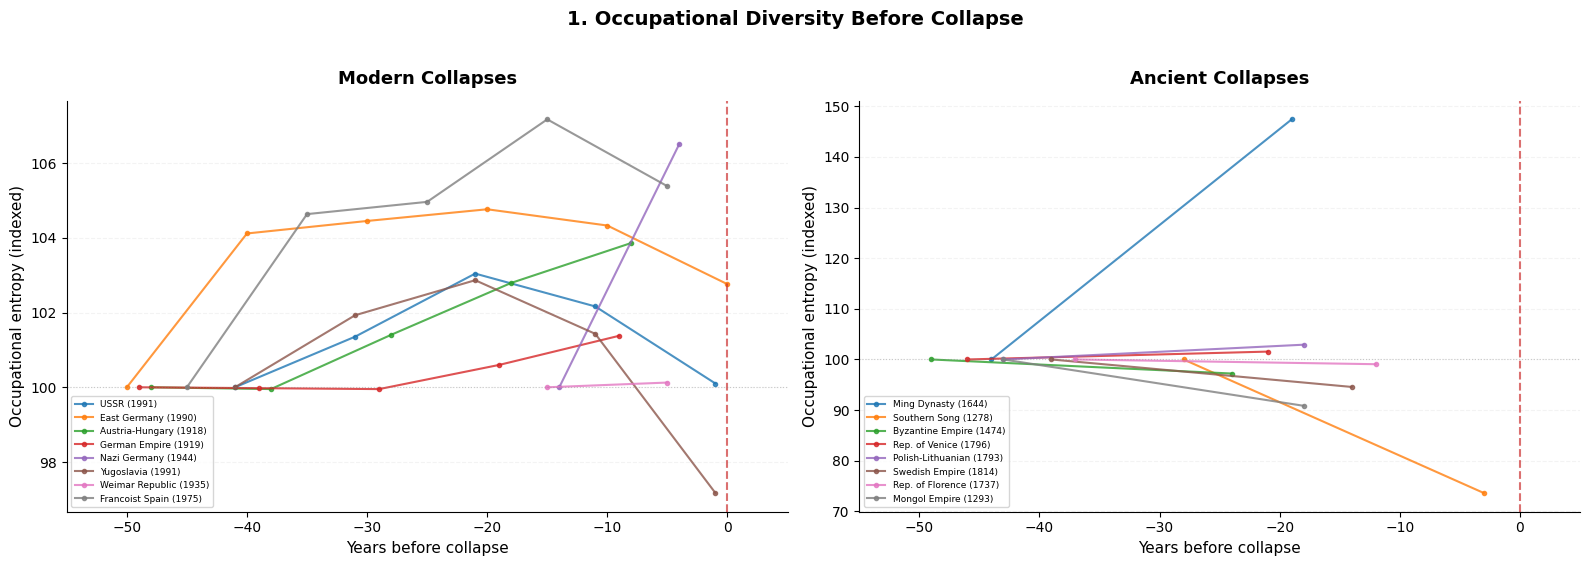

In [2]:
# ===== HYPOTHESIS 1: Occupational Entropy =====

def compute_entropy_curves(polities, bin_w):
    curves = []
    for label, polity_name, yr_start, yr_end in polities:
        rows = conn.execute('''
            SELECT ic.impact_date, i.occupations_en
            FROM individuals_cliopatria ic
            JOIN individuals i ON ic.wikidata_id = i.wikidata_id
            WHERE ic.polity_name = ?
              AND ic.impact_date IS NOT NULL
              AND i.occupations_en IS NOT NULL
        ''', (polity_name,)).fetchall()
        occ_by_bin = defaultdict(Counter)
        for year, occs in rows:
            b = (year // bin_w) * bin_w
            for occ in occs.split('; '):
                occ = occ.strip()
                if occ:
                    occ_by_bin[b][occ] += 1
        curve = []
        for b in sorted(occ_by_bin):
            t_rel = b - yr_end
            if -50 <= t_rel <= 0 and b >= (yr_start // bin_w) * bin_w:
                curve.append((t_rel, shannon_entropy(occ_by_bin[b])))
        if curve:
            curves.append((label, yr_end, normalize(curve)))
    return curves

ent_modern = compute_entropy_curves(modern, bin_modern)
ent_ancient = compute_entropy_curves(ancient, bin_ancient)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
for i, (label, yr_end, curve) in enumerate(ent_modern):
    ts, es = zip(*curve)
    ax1.plot(ts, es, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)
for i, (label, yr_end, curve) in enumerate(ent_ancient):
    ts, es = zip(*curve)
    ax2.plot(ts, es, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)

for ax, title in [(ax1, 'Modern Collapses'), (ax2, 'Ancient Collapses')]:
    ax.axvline(0, color='#cc3333', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(100, color='#888888', linestyle=':', linewidth=0.8, alpha=0.4)
    ax.set_xlim(-55, 5)
    ax.set_xlabel('Years before collapse', fontsize=11)
    ax.set_ylabel('Occupational entropy (indexed)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=6.5, loc='lower left', ncol=1, frameon=True, edgecolor='#cccccc')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
fig.suptitle('1. Occupational Diversity Before Collapse', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

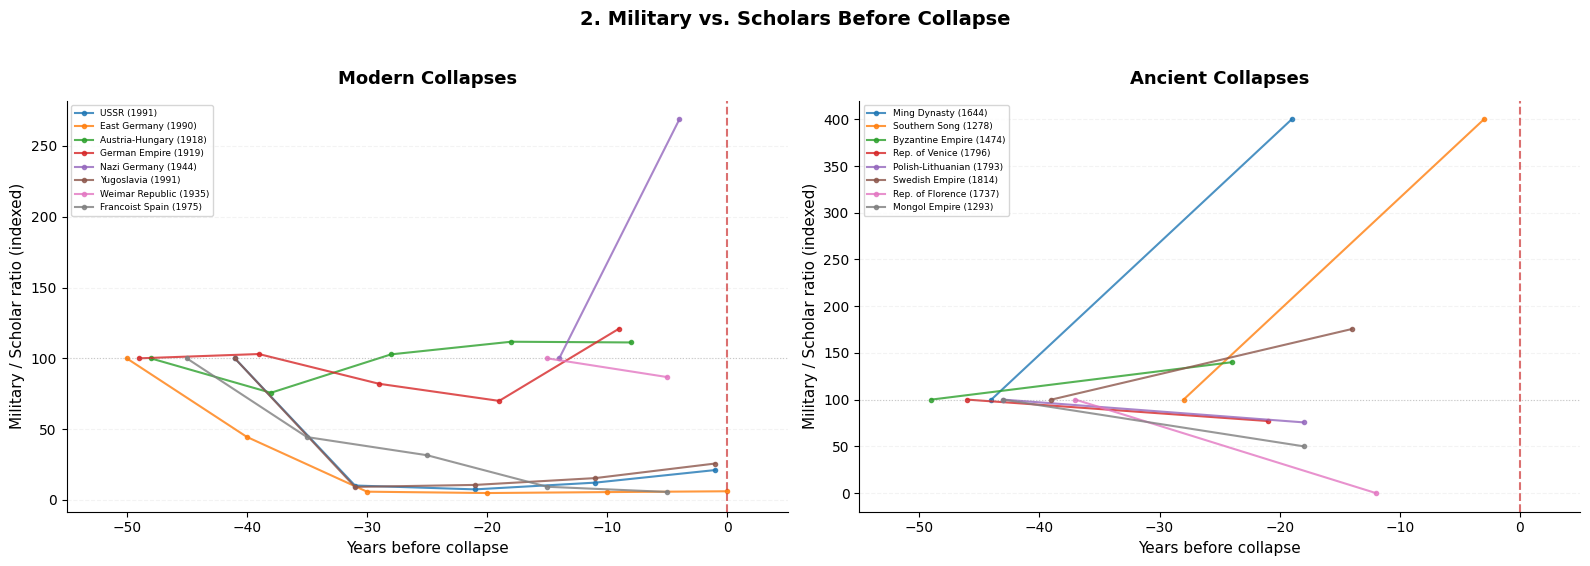

In [3]:
# ===== HYPOTHESIS 2: Military-to-Scholar ratio =====

def compute_mil_scholar(polities, bin_w):
    curves = []
    for label, polity_name, yr_start, yr_end in polities:
        mil_rows = conn.execute(f'''
            SELECT (ic.impact_date / {bin_w}) * {bin_w} as tb, COUNT(DISTINCT ic.wikidata_id)
            FROM individuals_cliopatria ic
            JOIN individuals i ON ic.wikidata_id = i.wikidata_id
            WHERE ic.polity_name = ? AND ({mil_cond}) AND ic.impact_date IS NOT NULL
            GROUP BY tb
        ''', (polity_name,)).fetchall()
        mil_map = {r[0]: r[1] for r in mil_rows}
        sch_rows = conn.execute(f'''
            SELECT (ic.impact_date / {bin_w}) * {bin_w} as tb, COUNT(DISTINCT ic.wikidata_id)
            FROM individuals_cliopatria ic
            JOIN individuals i ON ic.wikidata_id = i.wikidata_id
            WHERE ic.polity_name = ? AND ({sch_cond}) AND ic.impact_date IS NOT NULL
            GROUP BY tb
        ''', (polity_name,)).fetchall()
        sch_map = {r[0]: r[1] for r in sch_rows}
        curve = []
        for b in sorted(set(list(mil_map.keys()) + list(sch_map.keys()))):
            t_rel = b - yr_end
            if -50 <= t_rel <= 0 and b >= (yr_start // bin_w) * bin_w:
                m, s = mil_map.get(b, 0), sch_map.get(b, 0)
                ratio = m / s if s > 0 else (m if m > 0 else 0)
                curve.append((t_rel, ratio))
        if curve:
            curves.append((label, yr_end, normalize(curve)))
    return curves

ms_modern = compute_mil_scholar(modern, bin_modern)
ms_ancient = compute_mil_scholar(ancient, bin_ancient)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
for i, (label, yr_end, curve) in enumerate(ms_modern):
    ts, rs = zip(*curve)
    ax1.plot(ts, rs, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)
for i, (label, yr_end, curve) in enumerate(ms_ancient):
    ts, rs = zip(*curve)
    ax2.plot(ts, rs, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)

for ax, title in [(ax1, 'Modern Collapses'), (ax2, 'Ancient Collapses')]:
    ax.axvline(0, color='#cc3333', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(100, color='#888888', linestyle=':', linewidth=0.8, alpha=0.4)
    ax.set_xlim(-55, 5)
    ax.set_xlabel('Years before collapse', fontsize=11)
    ax.set_ylabel('Military / Scholar ratio (indexed)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=6.5, loc='upper left', ncol=1, frameon=True, edgecolor='#cccccc')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
fig.suptitle('2. Military vs. Scholars Before Collapse', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

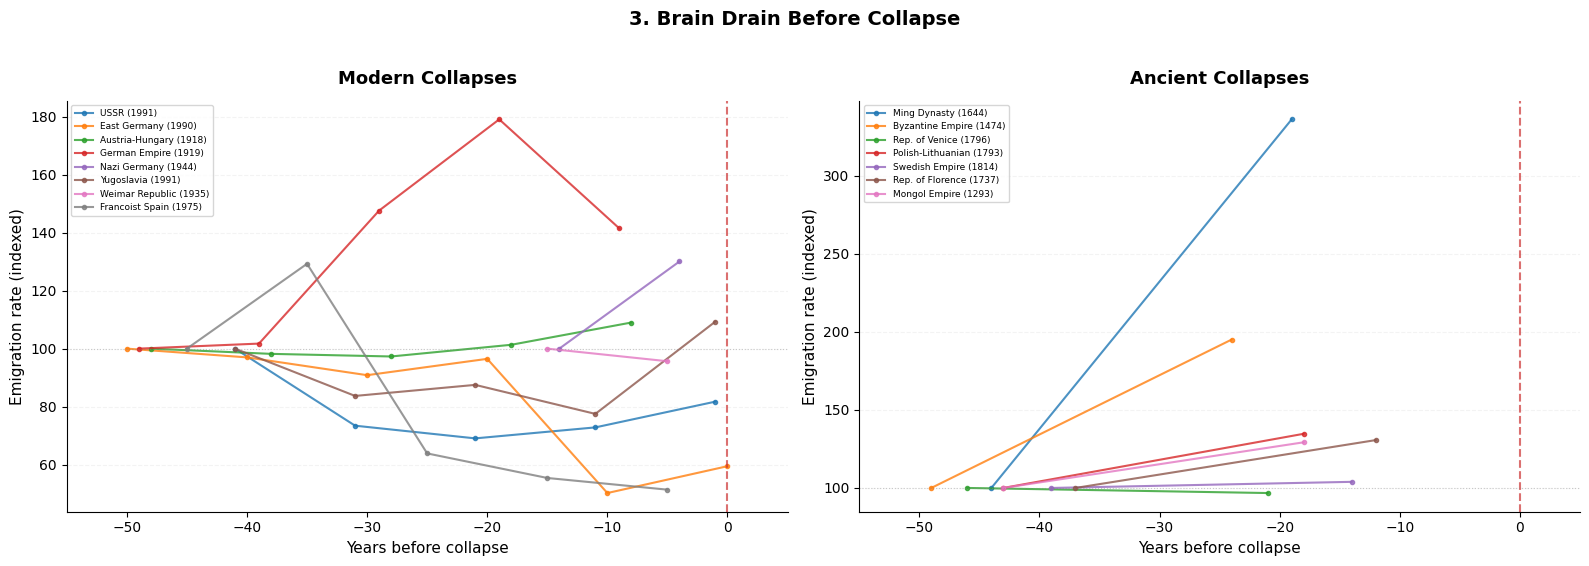

In [4]:
# ===== HYPOTHESIS 3: Brain Drain =====

def compute_brain_drain(polities, bin_w):
    curves = []
    for label, polity_name, yr_start, yr_end in polities:
        rows = conn.execute('''
            SELECT ic.impact_date,
                   bc.iso_a3_code, dc.iso_a3_code
            FROM individuals_cliopatria ic
            JOIN individuals_keys ik ON ic.wikidata_id = ik.wikidata_id
            LEFT JOIN cities bc ON ik.birthcity_id = bc.id
            LEFT JOIN cities dc ON ik.deathcity_id = dc.id
            WHERE ic.polity_name = ?
              AND ic.impact_date IS NOT NULL
              AND bc.iso_a3_code IS NOT NULL
              AND dc.iso_a3_code IS NOT NULL
        ''', (polity_name,)).fetchall()
        left_by_bin = defaultdict(int)
        total_by_bin = defaultdict(int)
        for year, bc, dc in rows:
            b = (year // bin_w) * bin_w
            total_by_bin[b] += 1
            if bc != dc:
                left_by_bin[b] += 1
        curve = []
        for b in sorted(total_by_bin):
            t_rel = b - yr_end
            if -50 <= t_rel <= 0 and b >= (yr_start // bin_w) * bin_w and total_by_bin[b] >= 5:
                curve.append((t_rel, left_by_bin[b] / total_by_bin[b] * 100))
        if curve:
            curves.append((label, yr_end, normalize(curve)))
    return curves

bd_modern = compute_brain_drain(modern, bin_modern)
bd_ancient = compute_brain_drain(ancient, bin_ancient)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
for i, (label, yr_end, curve) in enumerate(bd_modern):
    ts, es = zip(*curve)
    ax1.plot(ts, es, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)
for i, (label, yr_end, curve) in enumerate(bd_ancient):
    ts, es = zip(*curve)
    ax2.plot(ts, es, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)

for ax, title in [(ax1, 'Modern Collapses'), (ax2, 'Ancient Collapses')]:
    ax.axvline(0, color='#cc3333', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(100, color='#888888', linestyle=':', linewidth=0.8, alpha=0.4)
    ax.set_xlim(-55, 5)
    ax.set_xlabel('Years before collapse', fontsize=11)
    ax.set_ylabel('Emigration rate (indexed)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=6.5, loc='upper left', ncol=1, frameon=True, edgecolor='#cccccc')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
fig.suptitle('3. Brain Drain Before Collapse', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

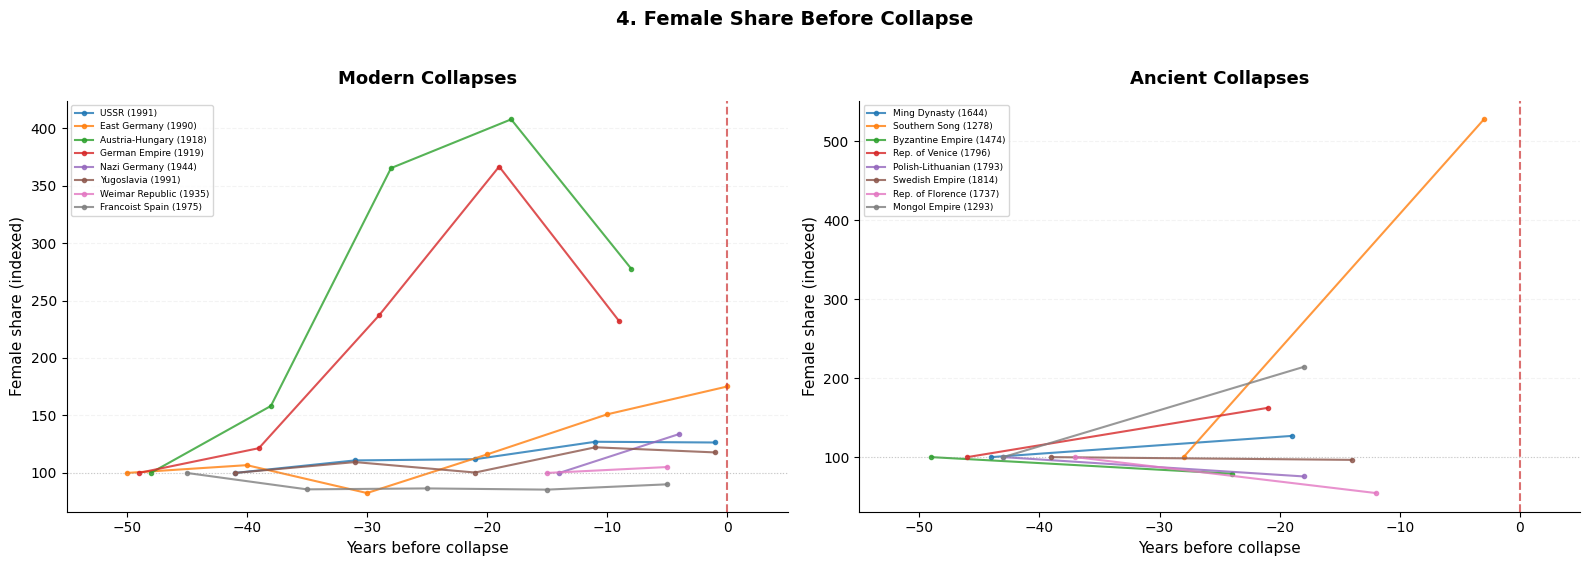

In [5]:
# ===== HYPOTHESIS 4: Gender ratio =====

def compute_gender(polities, bin_w):
    curves = []
    for label, polity_name, yr_start, yr_end in polities:
        rows = conn.execute(f'''
            SELECT (impact_year / {bin_w}) * {bin_w} as tb,
                   SUM(CASE WHEN gender = 'female' THEN 1 ELSE 0 END) as f,
                   COUNT(*) as t
            FROM consolidate
            WHERE polity_name = ? AND impact_year IS NOT NULL
            GROUP BY tb
        ''', (polity_name,)).fetchall()
        curve = []
        for b, f, t in rows:
            t_rel = b - yr_end
            if -50 <= t_rel <= 0 and b >= (yr_start // bin_w) * bin_w and t >= 10:
                curve.append((t_rel, f / t * 100))
        if curve:
            curves.append((label, yr_end, normalize(curve)))
    return curves

gn_modern = compute_gender(modern, bin_modern)
gn_ancient = compute_gender(ancient, bin_ancient)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
for i, (label, yr_end, curve) in enumerate(gn_modern):
    ts, gs = zip(*curve)
    ax1.plot(ts, gs, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)
for i, (label, yr_end, curve) in enumerate(gn_ancient):
    ts, gs = zip(*curve)
    ax2.plot(ts, gs, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)

for ax, title in [(ax1, 'Modern Collapses'), (ax2, 'Ancient Collapses')]:
    ax.axvline(0, color='#cc3333', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(100, color='#888888', linestyle=':', linewidth=0.8, alpha=0.4)
    ax.set_xlim(-55, 5)
    ax.set_xlabel('Years before collapse', fontsize=11)
    ax.set_ylabel('Female share (indexed)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=6.5, loc='upper left', ncol=1, frameon=True, edgecolor='#cccccc')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
fig.suptitle('4. Female Share Before Collapse', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

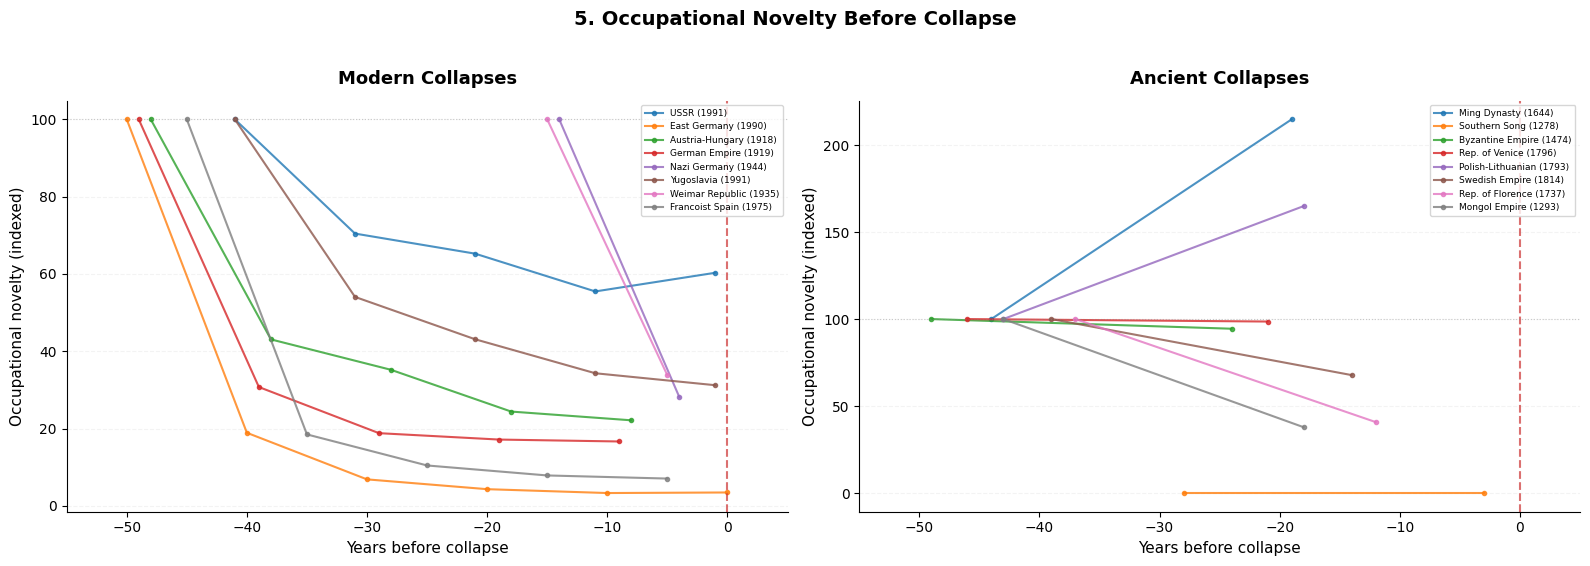

In [6]:
# ===== HYPOTHESIS 5: Occupational novelty =====

def compute_novelty(polities, bin_w):
    curves = []
    for label, polity_name, yr_start, yr_end in polities:
        rows = conn.execute('''
            SELECT ic.impact_date, i.occupations_en
            FROM individuals_cliopatria ic
            JOIN individuals i ON ic.wikidata_id = i.wikidata_id
            WHERE ic.polity_name = ?
              AND ic.impact_date IS NOT NULL
              AND i.occupations_en IS NOT NULL
            ORDER BY ic.impact_date
        ''', (polity_name,)).fetchall()
        seen_occs = set()
        new_per_bin = defaultdict(int)
        total_per_bin = defaultdict(int)
        for year, occs in rows:
            b = (year // bin_w) * bin_w
            for occ in occs.split('; '):
                occ = occ.strip()
                if occ:
                    total_per_bin[b] += 1
                    if occ not in seen_occs:
                        seen_occs.add(occ)
                        new_per_bin[b] += 1
        curve = []
        for b in sorted(total_per_bin):
            t_rel = b - yr_end
            if -50 <= t_rel <= 0 and b >= (yr_start // bin_w) * bin_w and total_per_bin[b] >= 10:
                curve.append((t_rel, new_per_bin.get(b, 0) / total_per_bin[b] * 100))
        if curve:
            curves.append((label, yr_end, normalize(curve)))
    return curves

nv_modern = compute_novelty(modern, bin_modern)
nv_ancient = compute_novelty(ancient, bin_ancient)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))
for i, (label, yr_end, curve) in enumerate(nv_modern):
    ts, ns = zip(*curve)
    ax1.plot(ts, ns, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)
for i, (label, yr_end, curve) in enumerate(nv_ancient):
    ts, ns = zip(*curve)
    ax2.plot(ts, ns, '-o', color=cmap(i), label=f'{label} ({yr_end})',
             linewidth=1.5, markersize=3, alpha=0.8)

for ax, title in [(ax1, 'Modern Collapses'), (ax2, 'Ancient Collapses')]:
    ax.axvline(0, color='#cc3333', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(100, color='#888888', linestyle=':', linewidth=0.8, alpha=0.4)
    ax.set_xlim(-55, 5)
    ax.set_xlabel('Years before collapse', fontsize=11)
    ax.set_ylabel('Occupational novelty (indexed)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=6.5, loc='upper right', ncol=1, frameon=True, edgecolor='#cccccc')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
fig.suptitle('5. Occupational Novelty Before Collapse', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

conn.close()